## 5 - Loading Processed Data

In this step, we load processed video dataset from the previously notebook


In [1]:
import cv2
import glob
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
from PIL import Image
import random
from sklearn.model_selection import train_test_split
import torch
from tqdm import tqdm
import urllib.request

In [2]:
print("--- LOADING PROCESSED DATA ---")

load_path = "./processed_images/celeb_videos.csv"
celeb_video = pd.read_csv(load_path)

print(f"{len(celeb_video)} videos loaded!")
pd.set_option('display.max_colwidth', None)
display(celeb_video.sample(15))

--- LOADING PROCESSED DATA ---
54086 videos loaded!


,video,label,dataset,category,method,target,source,sequence,full_path,total_frames,fps,duration_sec,resolution
9580,id31_id28_0004.mp4,1,Celeb-DF-v3,FaceReenact,LivePortrait,id28,id31,id28,/Volumes/LUCIA'S HD/Celeb-DF-v3/Celeb-synthesis/FaceReenact/LivePortrait/id31_id28_0004.mp4,311,30.0,10.366667,850x472
44163,id41_0002_test_id01000_yCKyUiCDAWQ.mp4,1,Celeb-DF-v3,TalkingFace,FLOAT,id01000,id41,0002,/Volumes/LUCIA'S HD/Celeb-DF-v3/Celeb-synthesis/TalkingFace/FLOAT/id41_0002_test_id01000_yCKyUiCDAWQ.mp4,375,25.0,15.000000,512x512
49548,id33_0005_test_id04862_sdKxEspywqk.mp4,1,Celeb-DF-v3,TalkingFace,Real3DPortrait,id04862,id33,0005,/Volumes/LUCIA'S HD/Celeb-DF-v3/Celeb-synthesis/TalkingFace/Real3DPortrait/id33_0005_test_id04862_sdKxEspywqk.mp4,176,25.0,7.040000,512x512
35205,id37_0000_test_id07354_nfIBEJYZG7o.mp4,1,Celeb-DF-v3,TalkingFace,AniTalker,id07354,id37,0000,/Volumes/LUCIA'S HD/Celeb-DF-v3/Celeb-synthesis/TalkingFace/AniTalker/id37_0000_test_id07354_nfIBEJYZG7o.mp4,142,25.0,5.680000,256x256
5288,id24_id19_0000.mp4,1,Celeb-DF-v3,FaceReenact,HyperReenact,id19,id24,id19,/Volumes/LUCIA'S HD/Celeb-DF-v3/Celeb-synthesis/FaceReenact/HyperReenact/id24_id19_0000.mp4,101,25.0,4.040000,256x256
41741,id50_0008_test_id08456_kx4-wNTJXW0.mp4,1,Celeb-DF-v3,TalkingFace,EDTalk,id08456,id50,0008,/Volumes/LUCIA'S HD/Celeb-DF-v3/Celeb-synthesis/TalkingFace/EDTalk/id50_0008_test_id08456_kx4-wNTJXW0.mp4,168,25.0,6.720000,256x256
42999,id20_0000_test_id06484_emN4_wYY0k4.mp4,1,Celeb-DF-v3,TalkingFace,FLOAT,id06484,id20,0000,/Volumes/LUCIA'S HD/Celeb-DF-v3/Celeb-synthesis/TalkingFace/FLOAT/id20_0000_test_id06484_emN4_wYY0k4.mp4,143,25.0,5.720000,512x512
22477,id21_id2_0002.mp4,1,Celeb-DF-v3,FaceSwap,GHOST,id2,id21,id2,/Volumes/LUCIA'S HD/Celeb-DF-v3/Celeb-synthesis/FaceSwap/GHOST/id21_id2_0002.mp4,334,30.0,11.133333,852x480
17147,id1_id28_0004.mp4,1,Celeb-DF-v3,FaceSwap,Celeb-DF-v2,id28,id1,id28,/Volumes/LUCIA'S HD/Celeb-DF-v3/Celeb-synthesis/FaceSwap/Celeb-DF-v2/id1_id28_0004.mp4,409,30.0,13.633333,432x500
51294,id12_0000_test_id07414_hhYGsoX_H3g.mp4,1,Celeb-DF-v3,TalkingFace,SadTalker,id07414,id12,0000,/Volumes/LUCIA'S HD/Celeb-DF-v3/Celeb-synthesis/TalkingFace/SadTalker/id12_0000_test_id07414_hhYGsoX_H3g.mp4,152,25.0,6.080000,256x256


## 6 - Cross-Dataset Test Split

In this section, we prepare the Celeb-DF-v3 dataset for **Cross-Dataset Evaluation**. 

Since we are using this entire dataset strictly to test the generalization capabilities of a model trained on a different dataset, we do not need to perform a traditional Train/Validation/Test split. Instead, we assign **100%** of the data to the **Test** split. 

This ensures complete isolation from whatever training data the model has seen previously.

In [3]:
from sklearn.model_selection import train_test_split
import numpy as np

def split(array, test_size=0.30, val_size=0.50, random_state=42):
    train_t, temp_t = train_test_split(array, test_size=test_size, random_state=random_state)
    val_t, test_t = train_test_split(temp_t, test_size=val_size, random_state=random_state)
    return set(train_t), set(val_t), set(test_t)

def assign_split(series, train_set, val_set, test_set):
    conditions = [
        series.isna(),
        series.isin(train_set),
        series.isin(val_set),
        series.isin(test_set)
    ]
    
    choices = [
        'unknown',
        'train',
        'val',
        'test'
    ]

    return np.select(conditions, choices, default='unknown')

In [4]:
print("--- TARGET BASED SPLIT (per manipulation category) ---")

train_trg_set, val_trg_set, test_trg_set = set(), set(), set()

for category in celeb_video['method'].dropna().unique():
    cat_mask = celeb_video['method'] == category
    cat_targets = celeb_video[cat_mask]['target'].dropna().unique()
    
    if len(cat_targets) < 3:
        print(f"Category '{category}' has only {len(cat_targets)} unique targets — "
              f"assigned entirely to train")
        train_trg_set.update(cat_targets)
        continue
    
    train_trg_cat, val_trg_cat, test_trg_cat = split(cat_targets)
    
    train_trg_set = train_trg_set.union(train_trg_cat)
    val_trg_set = val_trg_set.union(val_trg_cat)
    test_trg_set = test_trg_set.union(test_trg_cat)

celeb_video['split_target_based'] = assign_split(celeb_video['target'], train_trg_set, val_trg_set, test_trg_set)

print("\nCount per split:")
print(celeb_video['split_target_based'].value_counts())

print("\nCategory proportions per split:")
print(celeb_video.groupby('split_target_based')['method'].value_counts(normalize=True).round(3))

overlap_check = celeb_video.dropna(subset=['target']).groupby('target')['split_target_based'].nunique()
leaking_targets = overlap_check[overlap_check > 1]
print(f"\nTargets present in more than one split (should be 0): {len(leaking_targets)}")
if len(leaking_targets) > 0:
    print(leaking_targets)

display(celeb_video.sample(10))

--- TARGET BASED SPLIT (per manipulation category) ---

Count per split:
split_target_based
train    46466
val       4499
test      3121
Name: count, dtype: int64

Category proportions per split:
split_target_based  method        
test                Celeb-DF-v2       0.131
                    BlendFace         0.047
                    GHOST             0.047
                    HifiFace          0.047
                    InSwapper         0.047
                                      ...  
val                 IP_LAP            0.026
                    EchoMimic         0.025
                    EDTalk            0.025
                    Real3DPortrait    0.025
                    original          0.022
Name: proportion, Length: 69, dtype: float64

Targets present in more than one split (should be 0): 0


,video,label,dataset,category,method,target,source,sequence,full_path,total_frames,fps,duration_sec,resolution,split_target_based
26416,id22_id21_0006.mp4,1,Celeb-DF-v3,FaceSwap,InSwapper,id21,id22,id21,/Volumes/LUCIA'S HD/Celeb-DF-v3/Celeb-synthesis/FaceSwap/InSwapper/id22_id21_0006.mp4,333,30.0,11.100000,846x476,train
47936,id57_0008_test_id05594_etgiFErH_K0.mp4,1,Celeb-DF-v3,TalkingFace,IP_LAP,id05594,id57,0008,/Volumes/LUCIA'S HD/Celeb-DF-v3/Celeb-synthesis/TalkingFace/IP_LAP/id57_0008_test_id05594_etgiFErH_K0.mp4,154,25.0,6.160000,256x256,train
25065,id33_id34_0002.mp4,1,Celeb-DF-v3,FaceSwap,HifiFace,id34,id33,id34,/Volumes/LUCIA'S HD/Celeb-DF-v3/Celeb-synthesis/FaceSwap/HifiFace/id33_id34_0002.mp4,452,30.0,15.066667,848x466,val
23736,id51_id58_0004.mp4,1,Celeb-DF-v3,FaceSwap,GHOST,id58,id51,id58,/Volumes/LUCIA'S HD/Celeb-DF-v3/Celeb-synthesis/FaceSwap/GHOST/id51_id58_0004.mp4,447,29.0,15.413793,856x478,train
15502,id32_id35_0002.mp4,1,Celeb-DF-v3,FaceSwap,BlendFace,id35,id32,id35,/Volumes/LUCIA'S HD/Celeb-DF-v3/Celeb-synthesis/FaceSwap/BlendFace/id32_id35_0002.mp4,494,30.0,16.466667,850x472,train
43150,id23_0000_test_id04006__bENbO3pwL0.mp4,1,Celeb-DF-v3,TalkingFace,FLOAT,id04006,id23,0000,/Volumes/LUCIA'S HD/Celeb-DF-v3/Celeb-synthesis/TalkingFace/FLOAT/id23_0000_test_id04006__bENbO3pwL0.mp4,293,25.0,11.720000,512x512,train
219,id31_0000.mp4,0,Celeb-DF-v3,Celeb-real,original,id31,id31,original,/Volumes/LUCIA'S HD/Celeb-DF-v3/Celeb-real/id31_0000.mp4,423,30.0,14.100000,850x472,train
33091,id39_id46_0002.mp4,1,Celeb-DF-v3,FaceSwap,UniFace,id46,id39,id46,/Volumes/LUCIA'S HD/Celeb-DF-v3/Celeb-synthesis/FaceSwap/UniFace/id39_id46_0002.mp4,310,30.0,10.333333,850x476,train
35747,id47_0008_test_id01593_a0WUtNJAo9k.mp4,1,Celeb-DF-v3,TalkingFace,AniTalker,id01593,id47,0008,/Volumes/LUCIA'S HD/Celeb-DF-v3/Celeb-synthesis/TalkingFace/AniTalker/id47_0008_test_id01593_a0WUtNJAo9k.mp4,159,25.0,6.360000,256x256,train
50664,id56_0005_test_id04570_udmR6rSO9kk.mp4,1,Celeb-DF-v3,TalkingFace,Real3DPortrait,id04570,id56,0005,/Volumes/LUCIA'S HD/Celeb-DF-v3/Celeb-synthesis/TalkingFace/Real3DPortrait/id56_0005_test_id04570_udmR6rSO9kk.mp4,144,25.0,5.760000,512x512,train


## 7 - Dataset Balancing & Frame Extraction

Before extracting frames, we first ensure a fair evaluation by creating a **perfectly balanced subset**. We match the number of Fake videos to the total number of Real videos (e.g., 890 vs 890), using stratified sampling to maintain an even distribution across all deepfake manipulation methods.

To prepare the dataset for testing, we then extract **1 representative frame** per video (`fpv=1`) and process them through our targeted pipeline:

* **SSD Face Detection**: We use OpenCV's DNN (ResNet-10 SSD) to detect faces. Detections are cropped with a 15% margin and padded into a square to prevent aspect-ratio distortion.
* **Fallback Method:** If the model fails to confidently detect a face, we automatically apply a static center crop.
* **Standardization**: Every extracted face is resized to **224x224 pixels**, which is the standard input size for most modern vision backbones.

In [ ]:
# CONFIGURATION
base_root = "CELEBDFV3_DATASET"
DETECTOR_DIR = Path.cwd().parent
fpv = 3
target_size = (224, 224)

df_to_process = celeb_video 

print(f"STARTING EXTRACTION: {len(df_to_process)} videos | {fpv} frames each")

os.makedirs(base_root, exist_ok=True)
for split_name in ["train", "val", "test", "unknown"]:
    for label_folder in ["original", "fake"]:
        os.makedirs(os.path.join(base_root, split_name, label_folder), exist_ok=True)

# Load SSD (Face Detector)
prototxt_path = DETECTOR_DIR / "Utility/FaceDetection/deploy.prototxt"
model_path = DETECTOR_DIR / "Utility/FaceDetection/res10_300x300_ssd_iter_140000.caffemodel"

net = cv2.dnn.readNetFromCaffe(prototxt_path, model_path)
net.setPreferableBackend(cv2.dnn.DNN_BACKEND_OPENCV)
net.setPreferableTarget(cv2.dnn.DNN_TARGET_CPU)

# Utility
def apply_static_center_crop(frame, target_size):
    h, w = frame.shape[:2]
    min_dim = min(h, w)
    start_x = (w - min_dim) // 2
    start_y = (h - min_dim) // 2
    crop_frame = frame[start_y:start_y+min_dim, start_x:start_x+min_dim]
    return cv2.resize(crop_frame, target_size, interpolation=cv2.INTER_AREA)

# MAIN LOOP
extracted_metadata = []

for idx, row in tqdm(df_to_process.iterrows(), total=len(df_to_process)):
    video_path = row['full_path']
    label_str = "original" if row['label'] == 0 else "fake"
    split_str = row['split_target_based']

    base_name = f"{row['target']}_{row['source']}_{row['method']}_{row['video'].replace('.mp4','')}"
    save_dir = os.path.join(base_root, split_str, label_str)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        continue

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames < fpv:
        cap.release()
        continue

    target_indices = np.linspace(0, total_frames - 1, fpv, dtype=int)

    for count, target_idx in enumerate(target_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, target_idx)
        ret, frame = cap.read()
        if not ret:
            continue

        processed_frame = None
        strategy = "cc"

        # Face Detection via SSD
        (h, w) = frame.shape[:2]
        blob = cv2.dnn.blobFromImage(frame, 1.0, (300, 300), (104.0, 177.0, 123.0))
        net.setInput(blob)
        detections = net.forward()

        if detections.shape[2] > 0:
            confidence = detections[0, 0, 0, 2]
            if confidence > 0.6:
                box = detections[0, 0, 0, 3:7] * np.array([w, h, w, h])
                x1, y1, x2, y2 = box.astype(int)

                w_b, h_b = x2 - x1, y2 - y1
                margin = int(max(w_b, h_b) * 0.15)
                cx1, cy1 = max(0, x1 - margin), max(0, y1 - margin)
                cx2, cy2 = min(w, x2 + margin), min(h, y2 + margin)

                crop_face = frame[cy1:cy2, cx1:cx2]
                if crop_face.size > 0:
                    fh, fw = crop_face.shape[:2]
                    side = max(fh, fw)
                    square = np.zeros((side, side, 3), np.uint8)
                    square[(side - fh)//2 : (side - fh)//2 + fh, (side - fw)//2 : (side - fw)//2 + fw] = crop_face
                    processed_frame = cv2.resize(square, target_size, interpolation=cv2.INTER_AREA)
                    strategy = "ssd"

        # Fallback if SSD fails
        if processed_frame is None:
            processed_frame = apply_static_center_crop(frame, target_size)

        # Saving process
        img_name = f"{base_name}_f{count}_{strategy}.jpg"
        save_path = os.path.join(save_dir, img_name)
        cv2.imwrite(save_path, processed_frame, [cv2.IMWRITE_JPEG_QUALITY, 95])

        extracted_metadata.append({
            'path': save_path,
            'label': row['label'],
            'split': split_str,
            'dataset': row['dataset'],   
            'method': row['method'],
            'target': row['target'],
            'source': row['source'],
        })

    cap.release()

celeb_frames = pd.DataFrame(extracted_metadata)

print(f"\n--- EXTRACTION COMPLETE: {len(celeb_frames)} frames saved ---")
print("\nDistribution per split:")
print(celeb_frames['split'].value_counts())
print("\nLabel distribution per split:")
print(celeb_frames.groupby('split')['label'].value_counts())

celeb_frames.sample(15)

STARTING EXTRACTION: 54086 videos | 3 frames each


100%|██████████| 54086/54086 [2:14:31<00:00,  6.70it/s]  



--- EXTRACTION COMPLETE: 162255 frames saved ---

Distribution per split:
split
train    139398
val       13497
test       9360
Name: count, dtype: int64

Label distribution per split:
split  label
test   1          9099
       0           261
train  1        137292
       0          2106
val    1         13197
       0           300
Name: count, dtype: int64


,path,label,split,dataset,method,target,source
137351,CELEBDFV3_DATASET/train/fake/id05999_id16_IP_LAP_id16_0012_test_id05999_Tqa_oC4TyJc_f2_ssd.jpg,1,train,Celeb-DF-v3,IP_LAP,id05999,id16
82735,CELEBDFV3_DATASET/train/fake/id3_id4_InSwapper_id4_id3_0003_f1_ssd.jpg,1,train,Celeb-DF-v3,InSwapper,id3,id4
138970,CELEBDFV3_DATASET/train/fake/id02317_id27_IP_LAP_id27_0006_test_id02317_E_kmpT-EfOg_f1_ssd.jpg,1,train,Celeb-DF-v3,IP_LAP,id02317,id27
7794,CELEBDFV3_DATASET/val/fake/id50_id55_DaGAN_id55_id50_0004_f0_ssd.jpg,1,val,Celeb-DF-v3,DaGAN,id50,id55
74436,CELEBDFV3_DATASET/train/fake/id1_id2_HifiFace_id2_id1_0002_f0_ssd.jpg,1,train,Celeb-DF-v3,HifiFace,id1,id2
132539,CELEBDFV3_DATASET/train/fake/id04656_id41_FLOAT_id41_0005_test_id04656_i6oaXe2lw1Q_f2_ssd.jpg,1,train,Celeb-DF-v3,FLOAT,id04656,id41
33928,CELEBDFV3_DATASET/val/fake/id34_id28_MCNET_id28_id34_0005_f1_ssd.jpg,1,val,Celeb-DF-v3,MCNET,id34,id28
130662,CELEBDFV3_DATASET/val/fake/id04232_id30_FLOAT_id30_0000_test_id04232__k0hgacT2zc_f0_ssd.jpg,1,val,Celeb-DF-v3,FLOAT,id04232,id30
86762,CELEBDFV3_DATASET/train/fake/id29_id32_MobileFaceSwap_id32_id29_0004_f2_ssd.jpg,1,train,Celeb-DF-v3,MobileFaceSwap,id29,id32
74117,CELEBDFV3_DATASET/train/fake/id21_id28_HifiFace_id28_id21_0008_f2_ssd.jpg,1,train,Celeb-DF-v3,HifiFace,id21,id28


## 8 - Visual Sanity Check 

This serves as a critical "sanity check" to verify that the frame extraction process completed successfully without generating corrupted or blank images

In [6]:
print("--- CELEB-DF-V3 SANITY CHECK (DATAFRAME vs DISK) ---")

expected_celeb = len(celeb_frames)

def count_celeb_frames(base_dir):
    if not os.path.exists(base_dir):
        return 0, 0, 0
    total, ssd, cc = 0, 0, 0
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.endswith('.jpg') or file.endswith('.png'):
                total += 1
                if '_ssd' in file:
                    ssd += 1
                elif '_cc' in file:
                    cc += 1
    return total, ssd, cc

# Execute physical count on disk
actual_celeb, celeb_ssd, celeb_cc = count_celeb_frames(base_root)

# Print statistics
print(f"\n--- GLOBAL CELEB-DF-V3 STATISTICS ---")
print(f"Frames in DataFrame (Expected): {expected_celeb}")
print(f"Frames on Disk (Found):         {actual_celeb}")

if expected_celeb == actual_celeb and expected_celeb > 0:
    print("STATUS: PERFECT! DataFrame and Disk are perfectly synced.")
elif actual_celeb == 0:
    print("STATUS: WARNING! No frames found on disk. Check the path.")
else:
    print(f"STATUS: MISMATCH! Difference of {abs(expected_celeb - actual_celeb)} frames.")

if actual_celeb > 0:
    print("-" * 35)
    print(f"Extraction Quality Check:")
    print(f"  -> SSD Detected Faces: {celeb_ssd} ({(celeb_ssd/actual_celeb)*100:.1f}%)")
    print(f"  -> Center Crop Fallback: {celeb_cc} ({(celeb_cc/actual_celeb)*100:.1f}%)")

    print("-" * 35)
    print(f"Class Balance Check on Disk (per split):")

    total_real, total_fake = 0, 0
    for split_name in ["train", "val", "test", "unknown"]:
        path_real = os.path.join(base_root, split_name, "original")
        path_fake = os.path.join(base_root, split_name, "fake")

        n_real = len([f for f in os.listdir(path_real) if f.endswith('.jpg')]) if os.path.exists(path_real) else 0
        n_fake = len([f for f in os.listdir(path_fake) if f.endswith('.jpg')]) if os.path.exists(path_fake) else 0

        if n_real + n_fake > 0:
            print(f"  [{split_name:8s}] Original: {n_real:6d} | Fake: {n_fake:6d} | Total: {n_real + n_fake}")

        total_real += n_real
        total_fake += n_fake

    print("-" * 35)
    print(f"  -> TOTAL Original (Real): {total_real}")
    print(f"  -> TOTAL Fake:            {total_fake}")

    # Cross-check anche contro il dataframe
    df_real = (celeb_frames['label'] == 0).sum()
    df_fake = (celeb_frames['label'] == 1).sum()
    print("-" * 35)
    print(f"DataFrame vs Disk cross-check:")
    print(f"  -> Real: df={df_real} | disk={total_real} | match={df_real == total_real}")
    print(f"  -> Fake: df={df_fake} | disk={total_fake} | match={df_fake == total_fake}")

print(f"\nAudit completed for Celeb-DF-v3.")

--- CELEB-DF-V3 SANITY CHECK (DATAFRAME vs DISK) ---

--- GLOBAL CELEB-DF-V3 STATISTICS ---
Frames in DataFrame (Expected): 162255
Frames on Disk (Found):         162255
STATUS: PERFECT! DataFrame and Disk are perfectly synced.
-----------------------------------
Extraction Quality Check:
  -> SSD Detected Faces: 161034 (99.2%)
  -> Center Crop Fallback: 1221 (0.8%)
-----------------------------------
Class Balance Check on Disk (per split):
  [train   ] Original:   2106 | Fake: 137292 | Total: 139398
  [val     ] Original:    300 | Fake:  13197 | Total: 13497
  [test    ] Original:    261 | Fake:   9099 | Total: 9360
-----------------------------------
  -> TOTAL Original (Real): 2667
  -> TOTAL Fake:            159588
-----------------------------------
DataFrame vs Disk cross-check:
  -> Real: df=2667 | disk=2667 | match=True
  -> Fake: df=159588 | disk=159588 | match=True

Audit completed for Celeb-DF-v3.



--- VISUALIZING RANDOM FRAMES FROM CELEB-DF-V3 ---


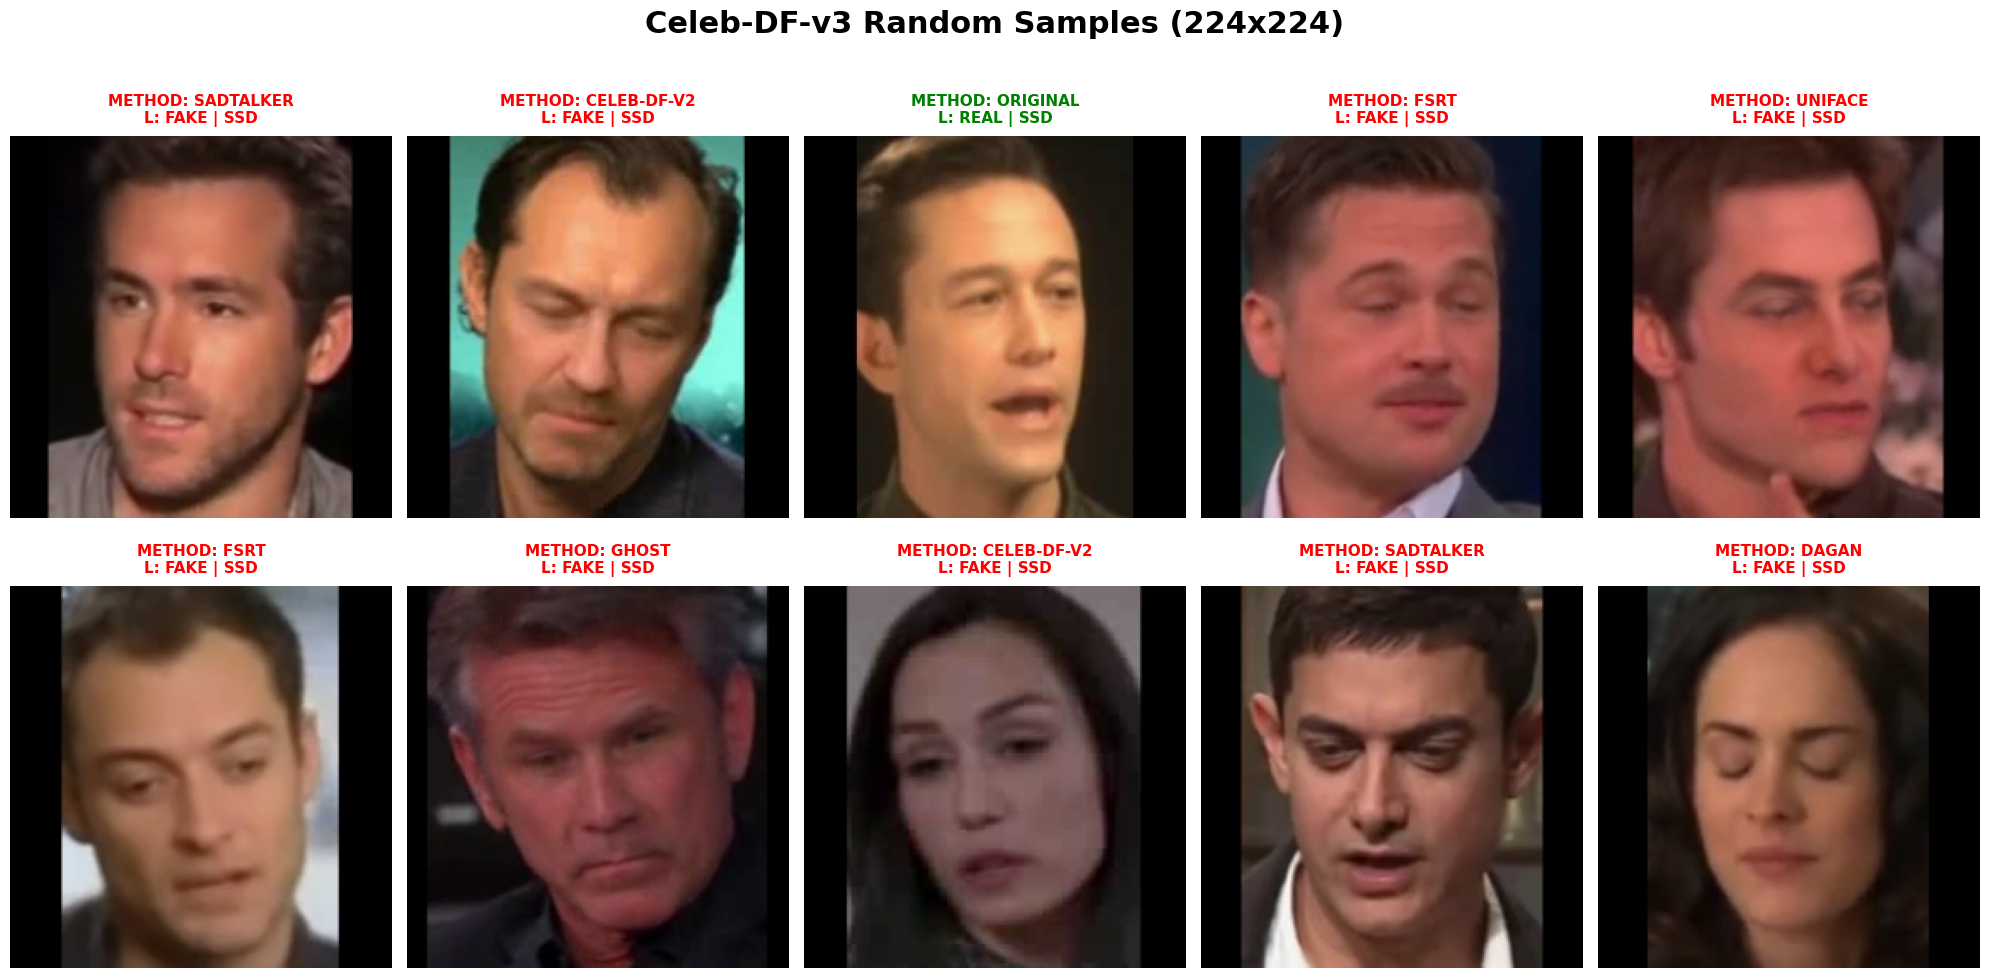

In [7]:
def show_celeb_frames_from_df(dataframe, num_images=10):
    print("\n--- VISUALIZING RANDOM FRAMES FROM CELEB-DF-V3 ---")
    
    sample = dataframe.sample(n=min(num_images, len(dataframe))).to_dict('records')
    
    if not sample:
        print("Zero images founded...")
        return 

    cols = 5
    rows = math.ceil(len(sample) / cols)
    
    plt.figure(figsize=(20, 5 * rows))
    plt.suptitle("Celeb-DF-v3 Random Samples (224x224)", fontsize=22, fontweight='bold', y=1.02)

    for i, row in enumerate(sample):
        plt.subplot(rows, cols, i+1)

        img_path = row['path']
        try:
            img = Image.open(img_path)
            plt.imshow(img)
        except Exception as e:
            plt.text(0.5, 0.5, 'Loading Error', ha='center', va='center')
            
        plt.axis('off')

        label_text = "REAL" if row['label'] == 0 else "FAKE"
        method_name = str(row['method']).upper()
        
        strategy = "SSD" if "_ssd" in img_path else "CC"
        
        title_color = 'green' if label_text == "REAL" else 'red'
        plt.title(f"METHOD: {method_name}\nL: {label_text} | {strategy}", 
                  color=title_color, fontsize=11, fontweight='bold', pad=10)

    plt.tight_layout()
    plt.show()

show_celeb_frames_from_df(celeb_frames, num_images=10)

## 8 - Saving Processed Data

To conclude this notebook, we save the fully cleaned and processed DataFrame to a local CSV file (`./processed_images/celeb_frames.csv`). This ensures our prepared dataset is safely stored and ready to be directly loaded into the next notebook of our pipeline without needing to re-run the preprocessing steps.

In [8]:
print("--- SAVING DATAFRAME ---")

output_dir = "./processed_images"
os.makedirs(output_dir, exist_ok=True)

save_path = os.path.join(output_dir, "celeb_frames.csv")
celeb_frames.to_csv(save_path, index=False)

print(f"Data succesfully saved to: {save_path}")

--- SAVING DATAFRAME ---
Data succesfully saved to: ./processed_images/celeb_frames.csv
